## 2026_Winter_DL_week5_Homework
CNN 실습 예제코드입니다!

이번 5주차 숙제는 총 2가지로 구성되어 있습니다.
- 논문 리뷰 - ResNet : https://arxiv.org/abs/1512.03385
    - 다음 논문을 읽고 팀별로 논문 스터디 및 정리를 준비해주시면 됩니다! (notion 이나 ppt 로 논문 정리 자료 제작 후에 팀별로 git에 업로드 해주세요 :D)

- 코드 과제 (아래 두 가지 중 택1!)
    - 1) (CNN 을 처음 접해보시거나 기초를 더 다지고 싶은 분들께 추천)
        - 아래 실습코드를 그대로 참고하셔도 좋고, 새롭게 짜셔도 좋습니다. 데이터셋은 CIFAR10이 아닌 벤치마크(MNIST, FFHQ, ImageNet)이나 다른 데이터셋을 사용하되, 학습 시간 및 리소스를 적절히 사용할 수 있는 화질을 사용하는 것을 추천 드립니다. 또한, 앞서 배운 regularization, initialization, optimizer 등등 기법을 추가해보시거나, layer를 변형하는 시도를 추가하여 결과를 분석해주세요.
        - example : Earlystopping 추가, Dropoutlayer 추가, batch nomalization 추가, stride 및 padding 변형, Conv layer 추가 및 삭제 등등
    - 2) (이미 CNN 지식이 있는 분들)
        - ResNet 을 논문 "**만**" 읽고 핵심 모듈 코드를 직접 짜보세요! 코드를 보지 않고 conv block이나 layer들을 논문 기반으로 짜보시면 됩니다.(임교수님께서 추천해주신 공부법입니다 ㅎㅎ)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.adam import Adam
from torch.utils.data.dataloader import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
from tqdm import tqdm

100%|██████████| 170M/170M [00:02<00:00, 77.2MB/s]
100%|██████████| 170M/170M [00:02<00:00, 75.6MB/s]


(32, 32, 3)


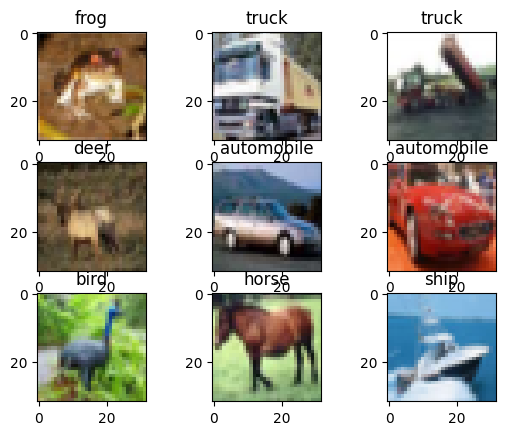

In [ ]:
# 데이터셋 정의 -> cifar-10
train_data = datasets.cifar.CIFAR10(
    './data/',
    train=True,
    download=True,
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.RandomHorizontalFlip(0.5),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ]))

'''
다음과 같이 정의하여 함수형태로 후처리도 가능합니다

transform=transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_data = data_transform(train_data)
'''


test_data = datasets.cifar.CIFAR10(
    root="../data/",
    train=False,
    download=True,
    transform=transforms.ToTensor())

for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(train_data.data[i])
    plt.title(train_data.classes[train_data.targets[i]])

print(train_data.data[0].shape)
plt.show()

In [ ]:
from torch.utils.data import Dataset

class CustomCIFAR10(Dataset):
    def __init__(self, root, train=True, download=False):
        # self.base_dataset = dataset.load_dataset(path = '')
        self.base_dataset = datasets.cifar.CIFAR10(
            root=root,
            train=train,
            download=download
        )

        self.train = train

        self.transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.RandomHorizontalFlip(0.5),
            transforms.RandomCrop(32, padding=4),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

    def __len__(self):
        return len(self.base_dataset.data)

    def __getitem__(self, idx):
        image = self.base_dataset.data[idx]  # numpy array (H, W, C)
        label = self.base_dataset.targets[idx]

        if self.train:
            image = self.transform(image)

        return image, label

# 인스턴스 생성
train_data = CustomCIFAR10(root='./data/', train=True, download=True)
test_data = CustomCIFAR10(root='./data/', train=False, download=True)

## Modeling

In [ ]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, hidden_dim):
        super(BasicBlock, self).__init__()

        self.conv1 = nn.Conv2d(in_channels, hidden_dim, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(hidden_dim, out_channels, kernel_size=3, padding=1)
        self.relu = nn.ReLU()

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        '''
        nn.Sequential 로 각 레이어를 묶어서 하나의 모델로 정의할 수도 있습니다!

        self.model = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
        '''

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        return x

        # return self.model(x)

In [ ]:
class CNN(nn.Module):
    def __init__(self, num_classes): # 클래스의 갯수
        super(CNN, self).__init__()

        # CNN 블럭 정의
        self.block1 = BasicBlock(in_channels=3, out_channels=32, hidden_dim=16)
        self.block2 = BasicBlock(in_channels=32, out_channels=128, hidden_dim=64)
        self.block3 = BasicBlock(in_channels=128, out_channels=256, hidden_dim=128)

        # classification을 위한 FC 정의
        self.fc1 = nn.Linear(in_features=4096, out_features=2048)
        self.fc2 = nn.Linear(in_features=2048, out_features=256)
        self.fc3 = nn.Linear(in_features=256, out_features=num_classes)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x) # 출력모양: (-1, 256, 4, 4)
        x = torch.flatten(x, start_dim=1) # 2차원의 feature map을 1차원으로

        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)

        return x

In [ ]:
from torch.utils.data.dataloader import DataLoader

from torch.optim.adam import Adam


# 데이터로더 정의
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# 학습을 진행할 프로세서 설정
device = "cuda" if torch.cuda.is_available() else "cpu"


print(f"device 정보: {device}")

# CNN 모델 정의
model = CNN(num_classes=10)

# 모델을 device로 보냄
model.to(device)

device 정보: cpu


CNN(
  (block1): BasicBlock(
    (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): BasicBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): BasicBlock(
    (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv2): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=4096, out_features=2048, bias=True)
  (fc2): Linear(in_features=2048, out_features=256,

In [8]:
# Learning rate
lr = 1e-3

# Optimizer
optim = Adam(model.parameters(), lr=lr)

# Train loop
for epoch in range(100):
    for data, label in tqdm(train_loader): # read data
        optim.zero_grad() # Iniitlaization

        preds = model(data.to(device)) # prediction

        # Loss Function
        loss = nn.CrossEntropyLoss()(preds, label.to(device))
        loss.backward()
        optim.step()

    if epoch==0 or epoch%10==9: # 10번마다 손실 출력
        print(f"epoch{epoch+1} loss:{loss.item()}")

# 모델 저장
torch.save(model.state_dict(), "CIFAR.pth")

 43%|████▎     | 335/782 [04:47<06:23,  1.16it/s]


KeyboardInterrupt: 

In [ ]:
model.load_state_dict(torch.load("CIFAR.pth", map_location=device))

num_corr = 0

with torch.no_grad():
    for data, label in tqdm(test_loader):
        output = model(data.to(device))
        preds = output.data.max(1)[1]
        corr = preds.eq(label.to(device).data).sum().item()
        num_corr += corr

    print(f"Accuracy:{num_corr/len(test_data)}")

100%|██████████| 157/157 [00:04<00:00, 36.56it/s]

Accuracy:0.84


# 과제

In [10]:
import torch, torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

device = "cuda" if torch.cuda.is_available() else "cpu"

train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])
test_tf = transforms.Compose([transforms.ToTensor()])

train_full = datasets.CIFAR10("./data", train=True, download=True, transform=train_tf)
test_set   = datasets.CIFAR10("./data", train=False, download=True, transform=test_tf)

train_set, val_set = random_split(train_full, [45000, 5000])

train_loader = DataLoader(train_set, batch_size=256, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set, batch_size=512, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set, batch_size=512, shuffle=False, num_workers=2, pin_memory=True)



In [11]:
class TinyCNN(nn.Module):
    def __init__(self, use_bn=False, dropout=0.0):
        super().__init__()
        def block(in_ch, out_ch):
            layers = [nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.ReLU()]
            if use_bn: layers.insert(1, nn.BatchNorm2d(out_ch))
            if dropout > 0: layers.append(nn.Dropout2d(dropout))
            layers.append(nn.MaxPool2d(2))
            return nn.Sequential(*layers)

        self.net = nn.Sequential(
            block(3, 32),   # 32->16
            block(32, 64),  # 16->8
            block(64, 128), # 8->4
            nn.Flatten(),
            nn.Linear(128*4*4, 256),
            nn.ReLU(),
            nn.Dropout(dropout) if dropout > 0 else nn.Identity(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        return self.net(x)


In [12]:
import copy

def eval_model(model, loader):
    model.eval()
    correct, total, loss_sum = 0, 0, 0.0
    crit = nn.CrossEntropyLoss()
    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(device), y.to(device)
            out = model(x)
            loss = crit(out,y)
            loss_sum += loss.item() * x.size(0)
            correct += (out.argmax(1)==y).sum().item()
            total += x.size(0)
    return loss_sum/total, correct/total

def train_one_epoch(model, loader, opt):
    model.train()
    crit = nn.CrossEntropyLoss()
    for x,y in loader:
        x,y = x.to(device), y.to(device)
        opt.zero_grad(set_to_none=True)
        out = model(x)
        loss = crit(out,y)
        loss.backward()
        opt.step()

def run(name, use_bn=False, dropout=0.0, opt_type="adam", wd=0.0, epochs=8):
    model = TinyCNN(use_bn=use_bn, dropout=dropout).to(device)

    if opt_type=="adam":
        opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=wd)
    else:
        opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=wd)

    best, best_state = 1e9, None
    patience, bad = 2, 0  # 코랩용: 빨리 멈추기

    for ep in range(1, epochs+1):
        train_one_epoch(model, train_loader, opt)
        val_loss, val_acc = eval_model(model, val_loader)
        print(f"{name} | ep{ep} val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

        if val_loss < best - 1e-4:
            best = val_loss
            best_state = copy.deepcopy(model.state_dict())
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                print("EarlyStop")
                break

    model.load_state_dict(best_state)
    test_loss, test_acc = eval_model(model, test_loader)
    print(f"✅ {name} TEST acc={test_acc:.4f}")
    return test_acc


In [ ]:
acc1 = run("Baseline", use_bn=False, dropout=0.0, opt_type="adam",  wd=0.0,  epochs=8)
acc2 = run("Improved", use_bn=True,  dropout=0.2, opt_type="adamw", wd=1e-4, epochs=8)

print("\n=== RESULT ===")
print("Baseline:", acc1)
print("Improved:", acc2)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Baseline | ep1 val_loss=1.6278 val_acc=0.4060
Baseline | ep2 val_loss=1.4197 val_acc=0.4982
Baseline | ep3 val_loss=1.3004 val_acc=0.5392
Baseline | ep4 val_loss=1.1788 val_acc=0.5786
Baseline | ep5 val_loss=1.1568 val_acc=0.5928
Baseline | ep6 val_loss=1.0519 val_acc=0.6178
Baseline | ep7 val_loss=1.0127 val_acc=0.6394
Baseline | ep8 val_loss=0.9775 val_acc=0.6574
✅ Baseline TEST acc=0.6867
